# Topics Comparison

Notebook for comparing `S3`, `FASTopic`, and a `TF-IDF` baseline on canonical Polymarket markets. The default text view is `full_description`, but every detector also supports `question` and `question_plus_full_description`.

In [1]:
from polymarket_research.data.canonical import CanonicalDatasetBuilder
from polymarket_research.data.raw import RawExternalCovariates, RawPolymarketHandle
from polymarket_research.utils import setup_root

from polymarket_research.research.topic_models import (
    FASTopicFactory,
    S3TopicFactory,
    TFIDFTopicFactory,
    build_topic_input_frame,
    compare_topic_factories,
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', None)
%matplotlib inline


/Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/_snmf.py:19: UserWarning: JAX not found, continuing with NumPy implementation.
  warnings.warn("JAX not found, continuing with NumPy implementation.")


In [2]:
REPO_ROOT = setup_root()
CANONICAL_CACHE_DIR = REPO_ROOT / "research_notebooks" / "running_artefacts_new" / "canonical_dataset"
MARKET_LIMIT = None
MARKET_ORDER = None  # one of: None, "latest", "largest"

if (CANONICAL_CACHE_DIR / "markets.parquet").exists() and MARKET_LIMIT is None and MARKET_ORDER is None:
    from polymarket_research.data.canonical import CanonicalDataset
    canonical = CanonicalDataset.from_parquet(CANONICAL_CACHE_DIR)
    print("Loaded canonical from parquet cache:", CANONICAL_CACHE_DIR)
else:
    raw_handle = RawPolymarketHandle()
    raw_bundle = raw_handle.load_bundle(
        include_market_universe=False,
        include_download_manifest=False,
        include_probabilities=True,
        include_raw_trades=False,
        market_limit=MARKET_LIMIT,
        market_order=MARKET_ORDER,
    )
    raw_external = RawExternalCovariates().load()
    canonical = CanonicalDatasetBuilder(
        raw_dataset=raw_bundle,
        raw_external=raw_external,
        resolved_only=True,
    ).build()
    if MARKET_LIMIT is None and MARKET_ORDER is None:
        canonical.save(CANONICAL_CACHE_DIR)
    print("Built canonical from SQLite")

all_markets = canonical.markets.copy()
probabilities = canonical.probabilities.copy()
print(f"Canonical resolved markets: {len(all_markets)}")
print("Market limit:", MARKET_LIMIT)
print("Market order:", MARKET_ORDER)
display(all_markets[["market_id", "question", "domain", "family_id", "volume_num"]].head(5))


Loaded canonical from parquet cache: /Users/sneddy/research/polymarket_research/research_notebooks/running_artefacts_new/canonical_dataset
Canonical resolved markets: 15662
Market limit: None
Market order: None


,market_id,question,domain,family_id,volume_num
0,1914442,"Will Hegseth say ""AI"" or ""Cyber"" during press conference?",unassigned,unassigned::::hegseth say ai or cyber during,38222.744674
1,1912772,"Trump announces US x Iran ceasefire end by April 8, 2026?",unassigned,unassigned::::trump announces us x iran ceasefire,38220.348645
2,1908626,Trump announces Hormuz deadline extension today?,unassigned,unassigned::::trump announces hormuz deadline extension today,987122.280619
3,1891746,"Will Trump say ""Strait"" or ""Hormuz"" during events with Rutte?",unassigned,unassigned::::trump say strait or hormuz during,27053.816874
4,1882888,Will Trump's remarks not air?,unassigned,unassigned::::trump s remarks not air,33098.189315


In [3]:
topic_markets = build_topic_input_frame(all_markets)
topic_markets["question_len"] = topic_markets["question"].fillna("").str.len()
topic_markets["full_description_len"] = topic_markets["full_description"].fillna("").str.len()

coverage = pd.DataFrame({
    "n_rows": [len(topic_markets)],
    "nonempty_question": [int(topic_markets["question"].fillna("").str.strip().ne("").sum())],
    "nonempty_full_description": [int(topic_markets["full_description"].fillna("").str.strip().ne("").sum())],
    "mean_question_len": [float(topic_markets["question_len"].mean())],
    "mean_full_description_len": [float(topic_markets["full_description_len"].mean())],
})
display(coverage)
display(topic_markets[["market_id", "question", "full_description", "volume_num"]].sample(2))

,n_rows,nonempty_question,nonempty_full_description,mean_question_len,mean_full_description_len
0,15662,15662,15662,57.048206,925.017558


,market_id,question,full_description,volume_num
8837,570831,Will US GDP growth in Q3 2025 be less than 1.0%?,"This market will resolve according to the seasonally adjusted and annualized GDP ""Advance Estimate"" release for Q3 of 2025 scheduled for October 30, 2025. If the reported value falls exactly between two brackets, then this market will resolve to the higher range bracket. The GDP release will be made available here: https://www.bea.gov/data/gdp/gross-domestic-product Note: data in the first available GDP report is labelled by the BEA as an ""Advance Estimate"". The data found in the advance estimate will be used to resolve this market. Data may be revised during the following quarter or as a part of the next estimate's publication, however any revisions to GDP report data made after the release of the advance estimate will not be considered for this market's resolution. US GDP growth in Q3 2025?",206529.777274
1460,1279765,Ilhan Omar federally charged by March 31?,"This market will resolve to ""Yes"" if the United States federal government formally charges or announces a criminal indictment of Ilhan Omar by March 31, 2026, 11:59 PM ET. Otherwise, this market will resolve to ""No"". For the purposes of this market, the District of Columbia and any county, municipality, or other subdivision of a State shall be included within the definition of a State. The primary resolution source for this market will be official information from US governmental sources; however, a wide consensus of credible reporting will also be used. Ilhan Omar federally charged by March 31?",76742.975022


## Run Config

Use `TEXT_MODE = "full_description"` for the description-centric view. Switch to `"question"` or `"question_plus_full_description"` to compare text views.

In [4]:
TEXT_MODE = "full_description"
N_TOPICS = 20
MIN_DF = 10
MAX_DF = 0.4
TOP_TERMS = 8
FASTOPIC_EPOCHS = 100
SAMPLE_SIZE = None
SORT_BY = "volume_num"
REDUCERS = ["umap", "tsne"]

work_markets = topic_markets.copy()
work_markets = work_markets.loc[work_markets[TEXT_MODE].fillna("").astype(str).str.strip().ne("")].copy()
if SORT_BY in work_markets.columns:
    work_markets = work_markets.sort_values(SORT_BY, ascending=False, kind="stable")
if SAMPLE_SIZE is not None:
    work_markets = work_markets.head(int(SAMPLE_SIZE)).copy()

print("Rows used for modeling:", len(work_markets))
display(work_markets[["market_id", "question", "full_description", "volume_num"]].sample(2))

Rows used for modeling: 15662


,market_id,question,full_description,volume_num
13899,525019,Will Jean-Claude Hollerich be the next pope?,"This market will resolve to the name of the next person announced as the bishop of Rome after Pope Francis. If no new pope is announced by December 31, 2025, 11:59 PM ET, this market will resolve to ""No new Pope in 2025"". The primary resolution source will be official information from the Vatican, however a consensus of credible reporting will also be used. Who will be the next Pope?",341608.642489
8873,570013,Will Trump agree to a tariff agreement with China in August?,"This market will resolve to ""Yes"" if an official agreement over tariffs, defined as a publicly announced mutual agreement, is reached between the United States and the listed country/entity between August 1, and August 31, 2025, 11:59 PM ET. Otherwise, this market will resolve to “No”. If such an agreement is officially reached before the resolution date, this market will resolve to ""Yes"", regardless of if/when the agreement goes into effect. Agreements to extend tariff exemptions will qualify if announced as an individualized extension. However, tariff exemptions which are announced as part of a class of exemptions and do not reflect individual deals - such as Trump’s April 9 pause on all reciprocal tariffs other than those on China - will not qualify (see: https://www.whitehouse.gov/presidential-actions/2025/04/modifying-reciprocal-tariff-rates-to-reflect-trading-partner-retaliation-and-alignment/). Informal and unilateral announcements which do not constitute a finalized agreement will not count. Agreements that include the United States and the listed country/entity as parties, even if they also involve other countries, will qualify for resolution. The primary resolution source for this market will be a consensus of credible reporting confirming an agreement has been reached. Which countries will the U.S. agree to tariff agreements with in August?",187263.826183


In [5]:
topic_factories = [
    S3TopicFactory(
        n_topics=N_TOPICS,
        text_mode=TEXT_MODE,
        min_df=MIN_DF,
        max_df=MAX_DF,
        top_terms=TOP_TERMS,
    ),
    FASTopicFactory(
        n_topics=N_TOPICS,
        text_mode=TEXT_MODE,
        min_df=MIN_DF,
        max_df=MAX_DF,
        top_terms=TOP_TERMS,
        n_epochs=FASTOPIC_EPOCHS,
    ),
    TFIDFTopicFactory(
        n_topics=N_TOPICS,
        text_mode=TEXT_MODE,
        min_df=MIN_DF,
        max_df=MAX_DF,
        top_terms=TOP_TERMS,
    ),
]

results, comparison_summary = compare_topic_factories(work_markets, topic_factories)
display(comparison_summary)

Output()

[20:01:48] Documents encoded.                                                                         ]8;id=513942;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=846008;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py#144\144]8;;\

           Decomposition done.                                                                        ]8;id=310945;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=841183;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py#151\151]8;;\

[20:01:49] Term extraction done.                                                                      ]8;id=994438;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=930587;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py#154\154]8;;\

[20:01:52] Vocabulary encoded.                                                                        ]8;id=532339;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=742381;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py#164\164]8;;\

...

Output()

[20:04:03] Documents encoded.                                                                       ]8;id=842938;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/fastopic.py\fastopic.py]8;;\:]8;id=957239;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/fastopic.py#157\157]8;;\

[20:04:04] Term extraction done.                                                                    ]8;id=337078;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/fastopic.py\fastopic.py]8;;\:]8;id=925611;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/fastopic.py#161\161]8;;\

[20:04:41] Model fitting done.                                                                      ]8;id=350223;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/fastopic.py\fastopic.py]8;;\:]8;id=754128;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/fastopic.py#164\164]8;;\

,model_name,text_mode,n_documents,n_topics,runtime_seconds,mean_topic_confidence
0,TFIDF,full_description,15662,20,1.433162,0.075103
1,S3,full_description,15662,20,115.777495,0.347092
2,FASTopic,full_description,15662,20,163.237032,0.201133


In [6]:
for model_name, result in results.items():
    print("=" * 100)
    print(model_name)
    display(result.topic_summary()[["topic_id", "topic_label", "topic_size"]])

S3


,topic_id,topic_label,topic_size
0,15,"topic_15: uefa, fifa, time fifa, uefa champions",1239
1,1,"topic_1: people 2025, global people, 2025 winner, winner 2025",1039
2,8,"topic_8: mayoral election, city mayoral, nyc mayoral, mayoral",991
3,10,"topic_10: cast, film comes, market yes, yes according",971
4,3,"topic_3: context joyful, pluralization, words count, word joy",960
5,7,"topic_7: trump meet, meets donald, bilateral meeting, individual meets",940
6,5,"topic_5: strike iranian, strikes iran, impact iranian, iranian ground",917
7,13,"topic_13: super bowl, nfl, nfc, rules nfl",888
8,6,"topic_6: opening weekend, weekend box, domestically opening, movie numbers",851
9,0,"topic_0: binance minute, yes binance, market binance, btc usdt",843


FASTopic


,topic_id,topic_label,topic_size
0,0,"topic_0: election, party, vote, seats",1490
1,17,"topic_17: completed game, resolve point, fight, team win",1171
2,9,"topic_9: strike, territory, missiles, ground",1010
3,4,"topic_4: term, compound, word, events",992
4,15,"topic_15: tournament, player, eurovision, gold",967
5,14,"topic_14: handshake, executive order, resignation, individuals",935
6,19,"topic_19: token, launch, suffice, korea",876
7,13,"topic_13: year search, spotify, global, search",875
8,18,"topic_18: isw, russia, map, isw map",844
9,1,"topic_1: domestic refers, opening weekend, box office, numbers figures",769


TFIDF


,topic_id,topic_label,topic_size
0,6,"topic_6: trump, 31, qualify, 2025 11",5854
1,17,"topic_17: winner, eurovision, team, 2026",1682
2,3,"topic_3: election, round, presidential, candidate",980
3,5,"topic_5: count, term, event, trump",956
4,13,"topic_13: weekend, box office, box, office",583
5,9,"topic_9: leaderboard, arena, ai, arena score",569
6,7,"topic_7: strike, missiles, ground, israeli",520
7,12,"topic_12: tournament, player, open, championship",512
8,11,"topic_11: price, binance, minute, trading",463
9,4,"topic_4: academy, awards, award, best",451


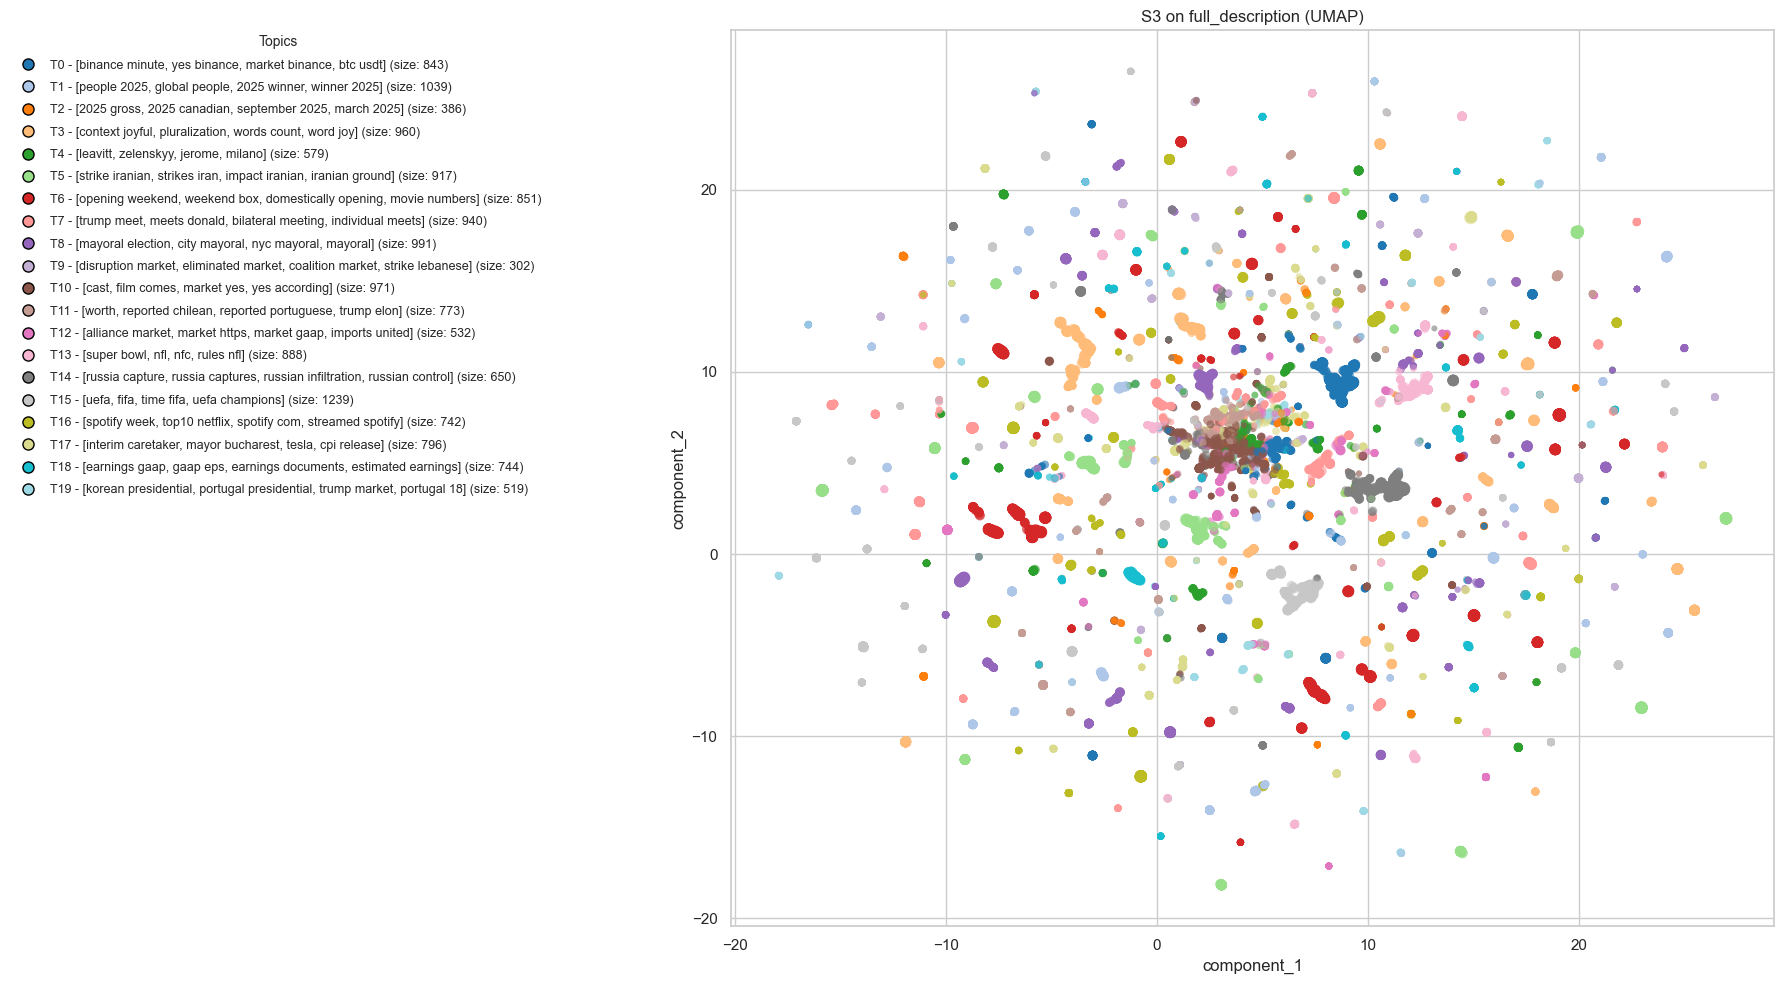

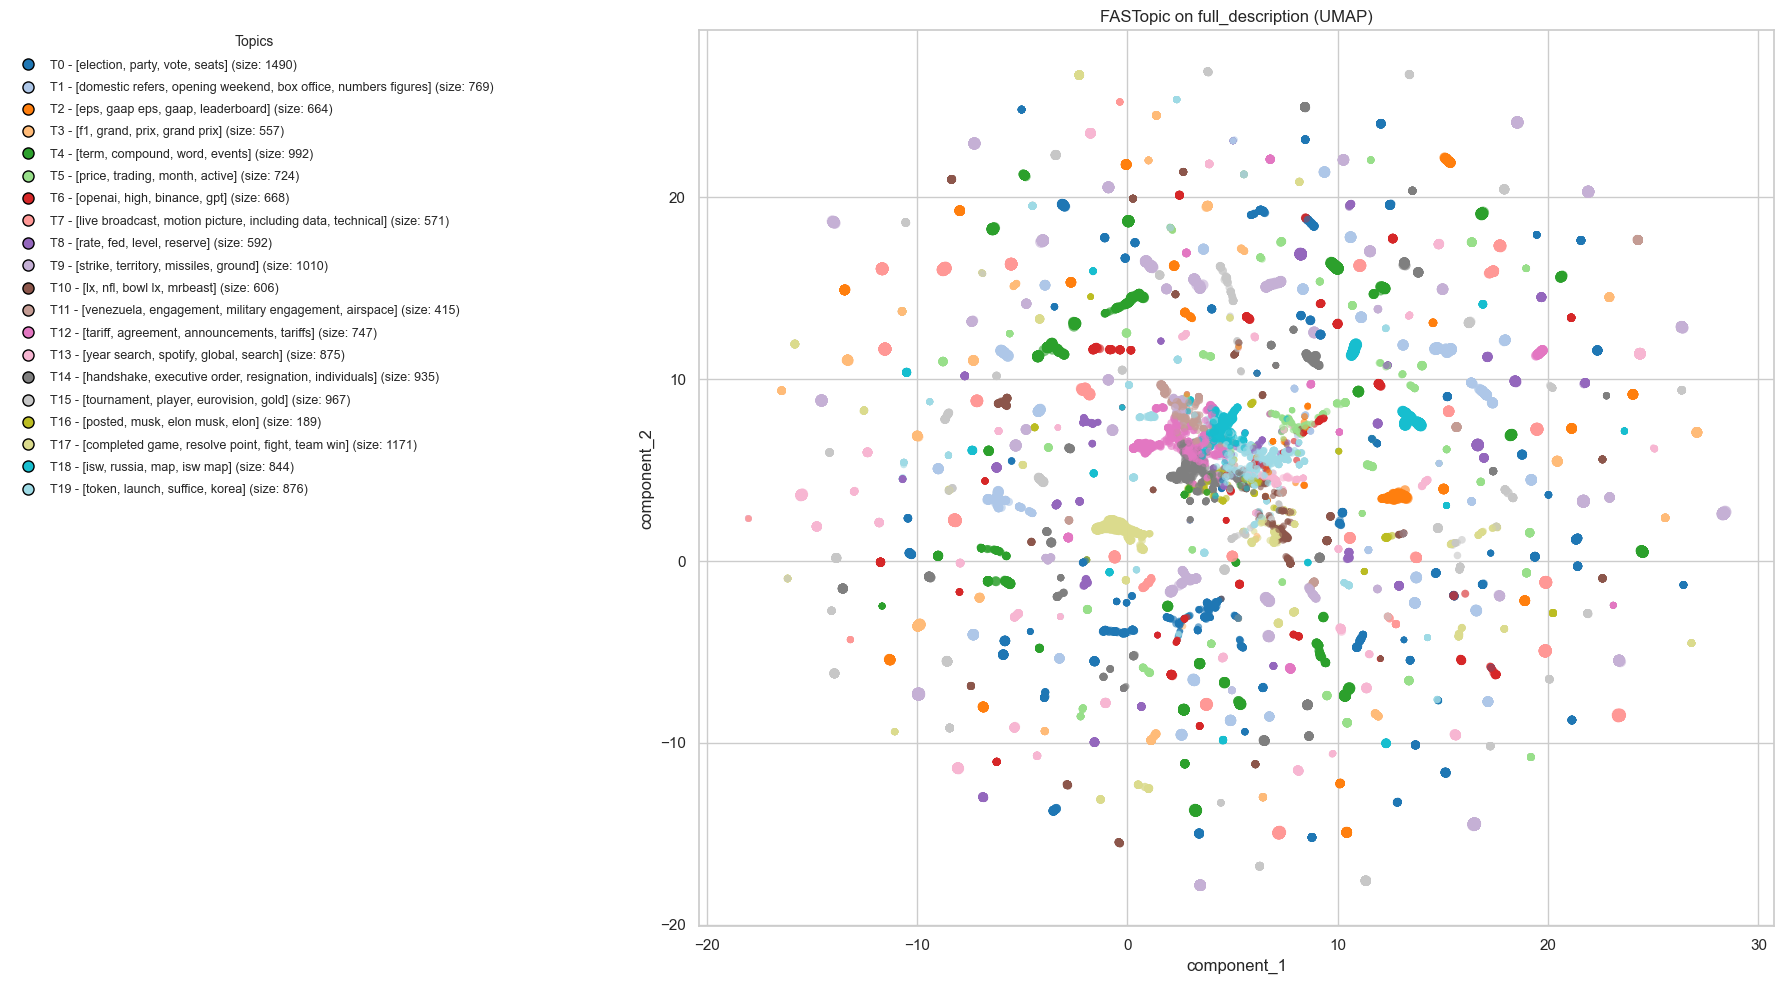

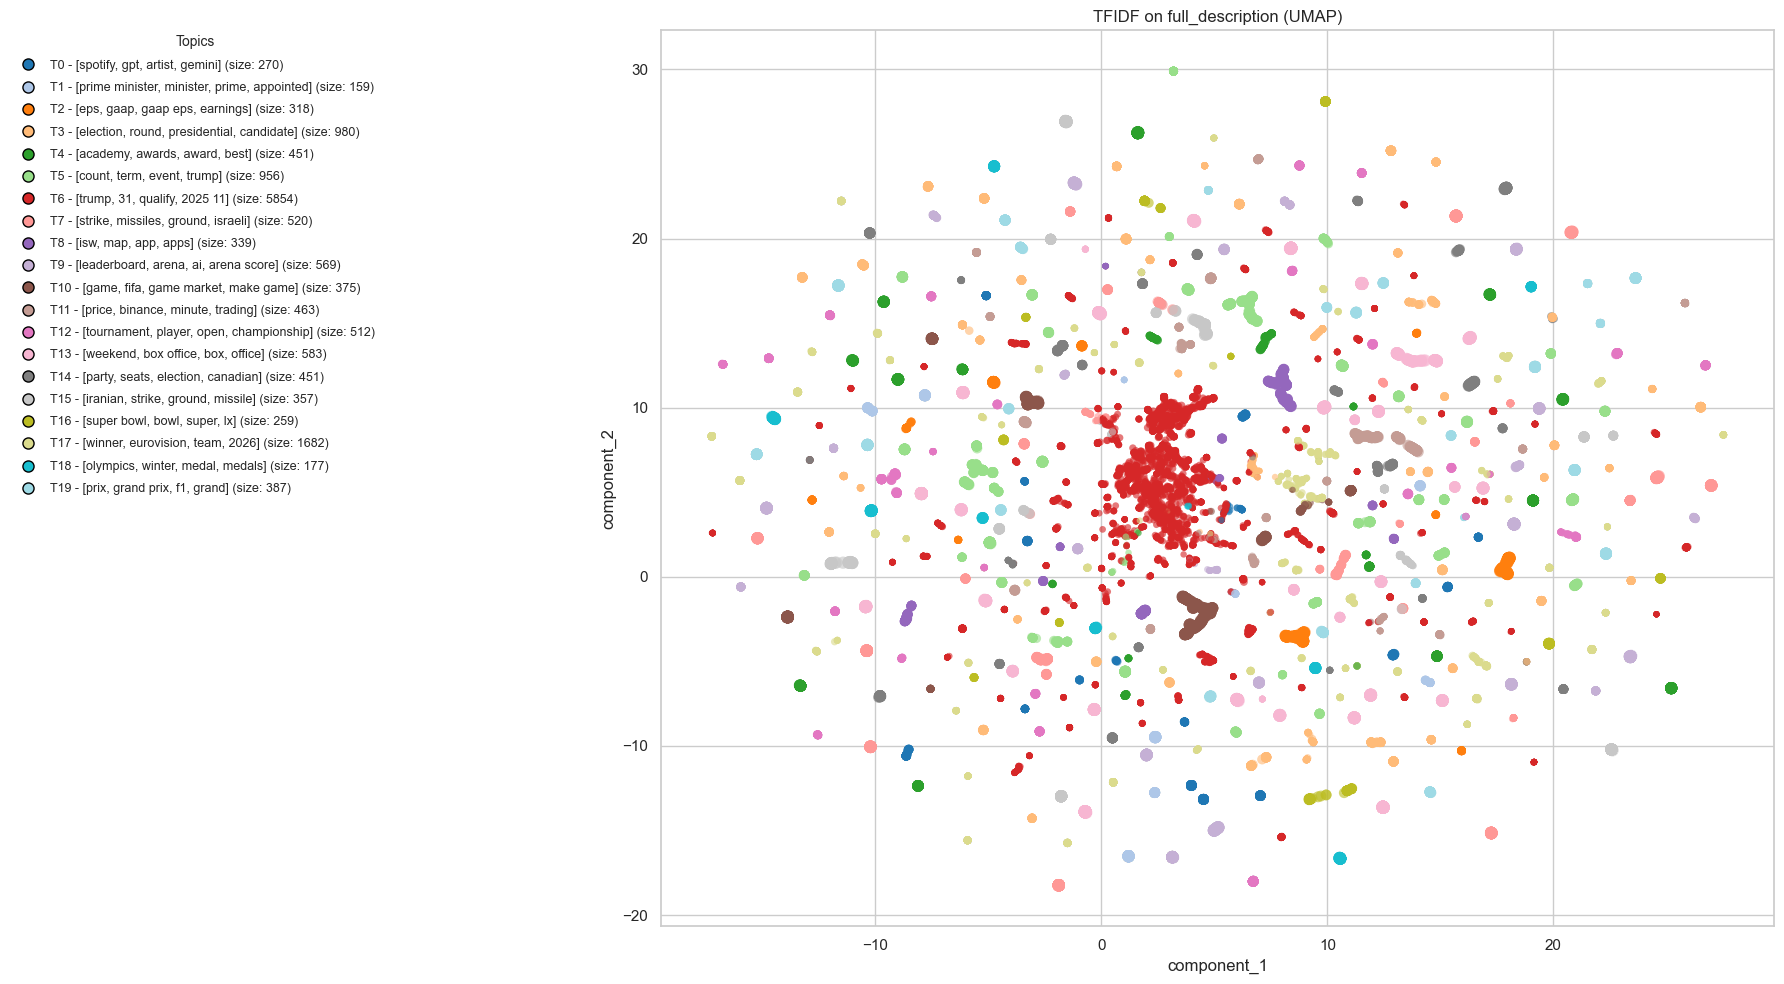

In [7]:
for model_name, result in results.items():
    fig, axes, projected = result.plot_2d_with_topic_map(
        reducer="umap",
        random_state=0,
        legend_mode="full",
        show_table=False,
        figsize=(18, 10),
    )
    plt.show()

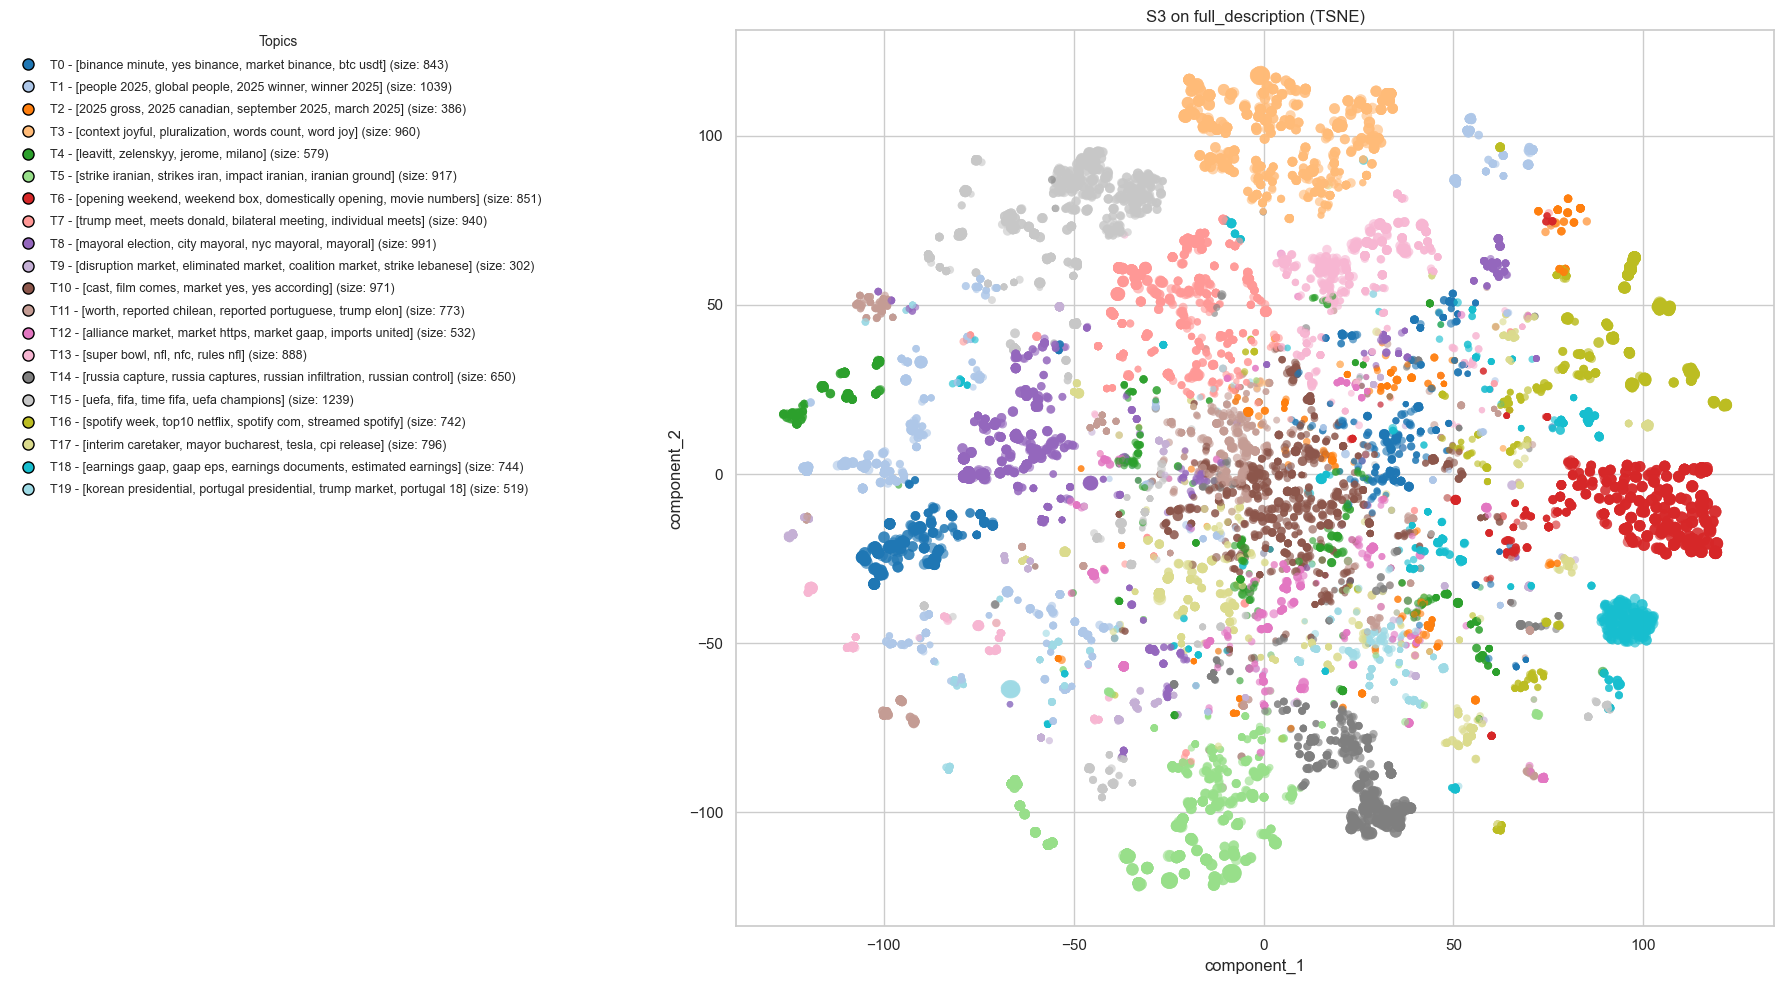

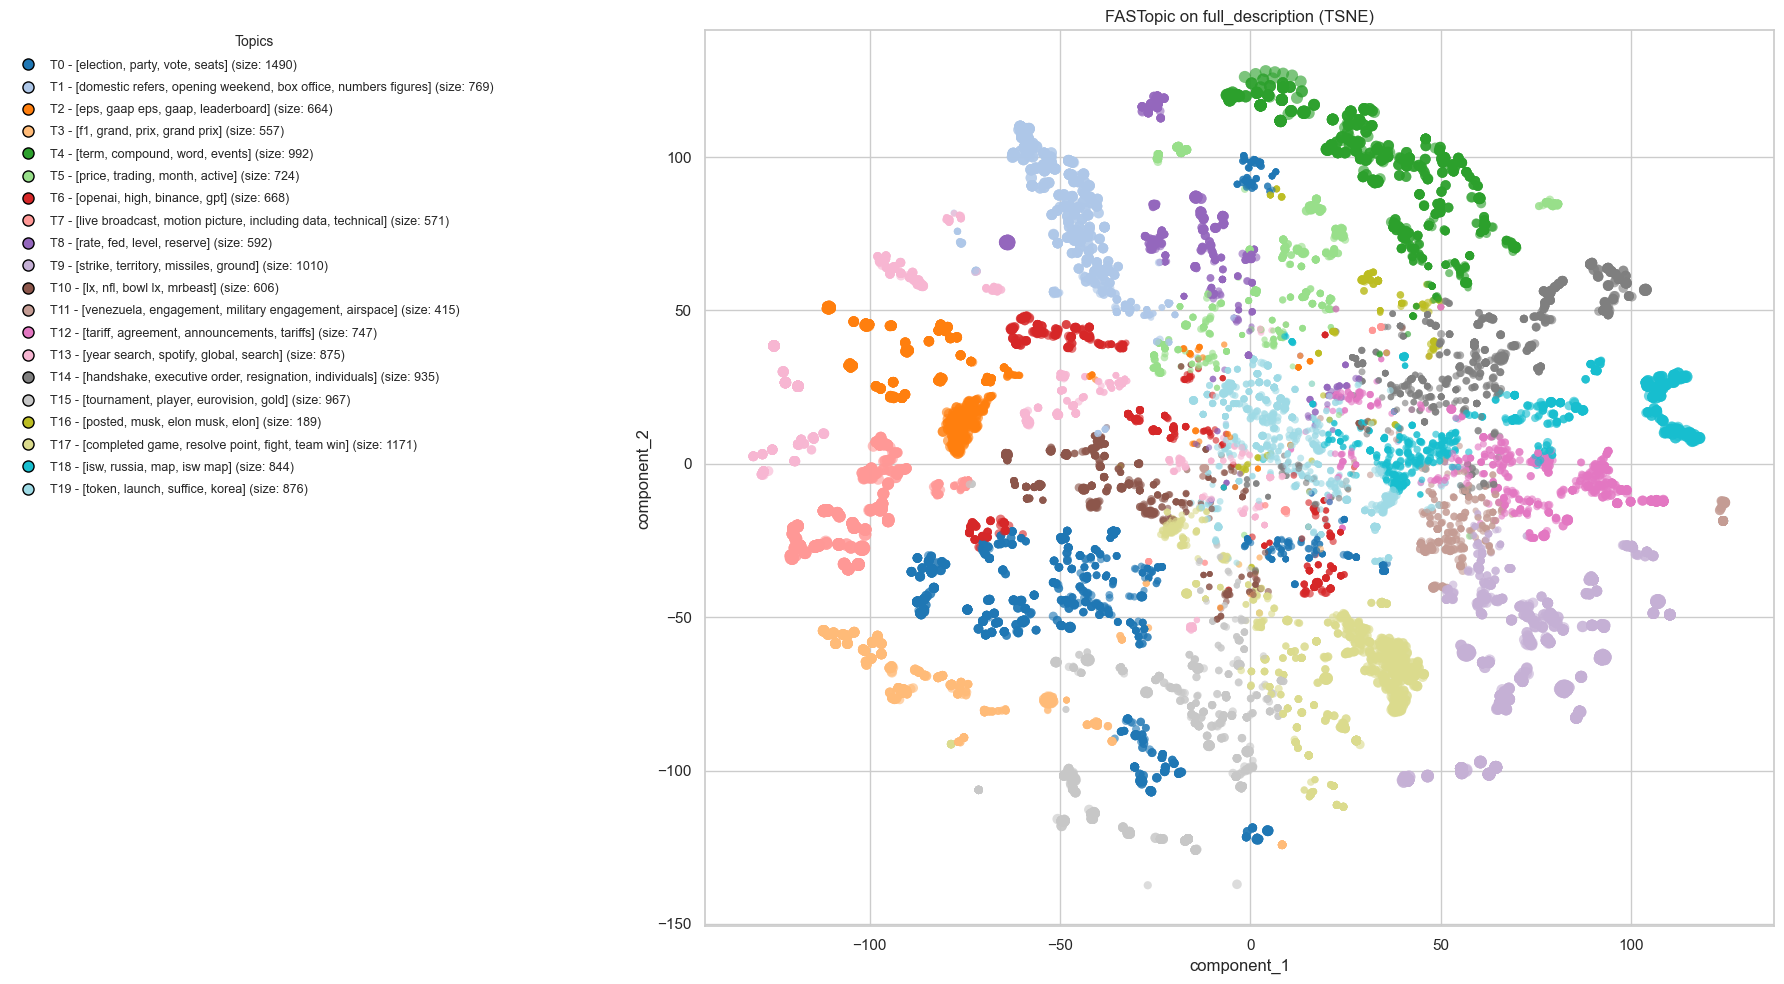

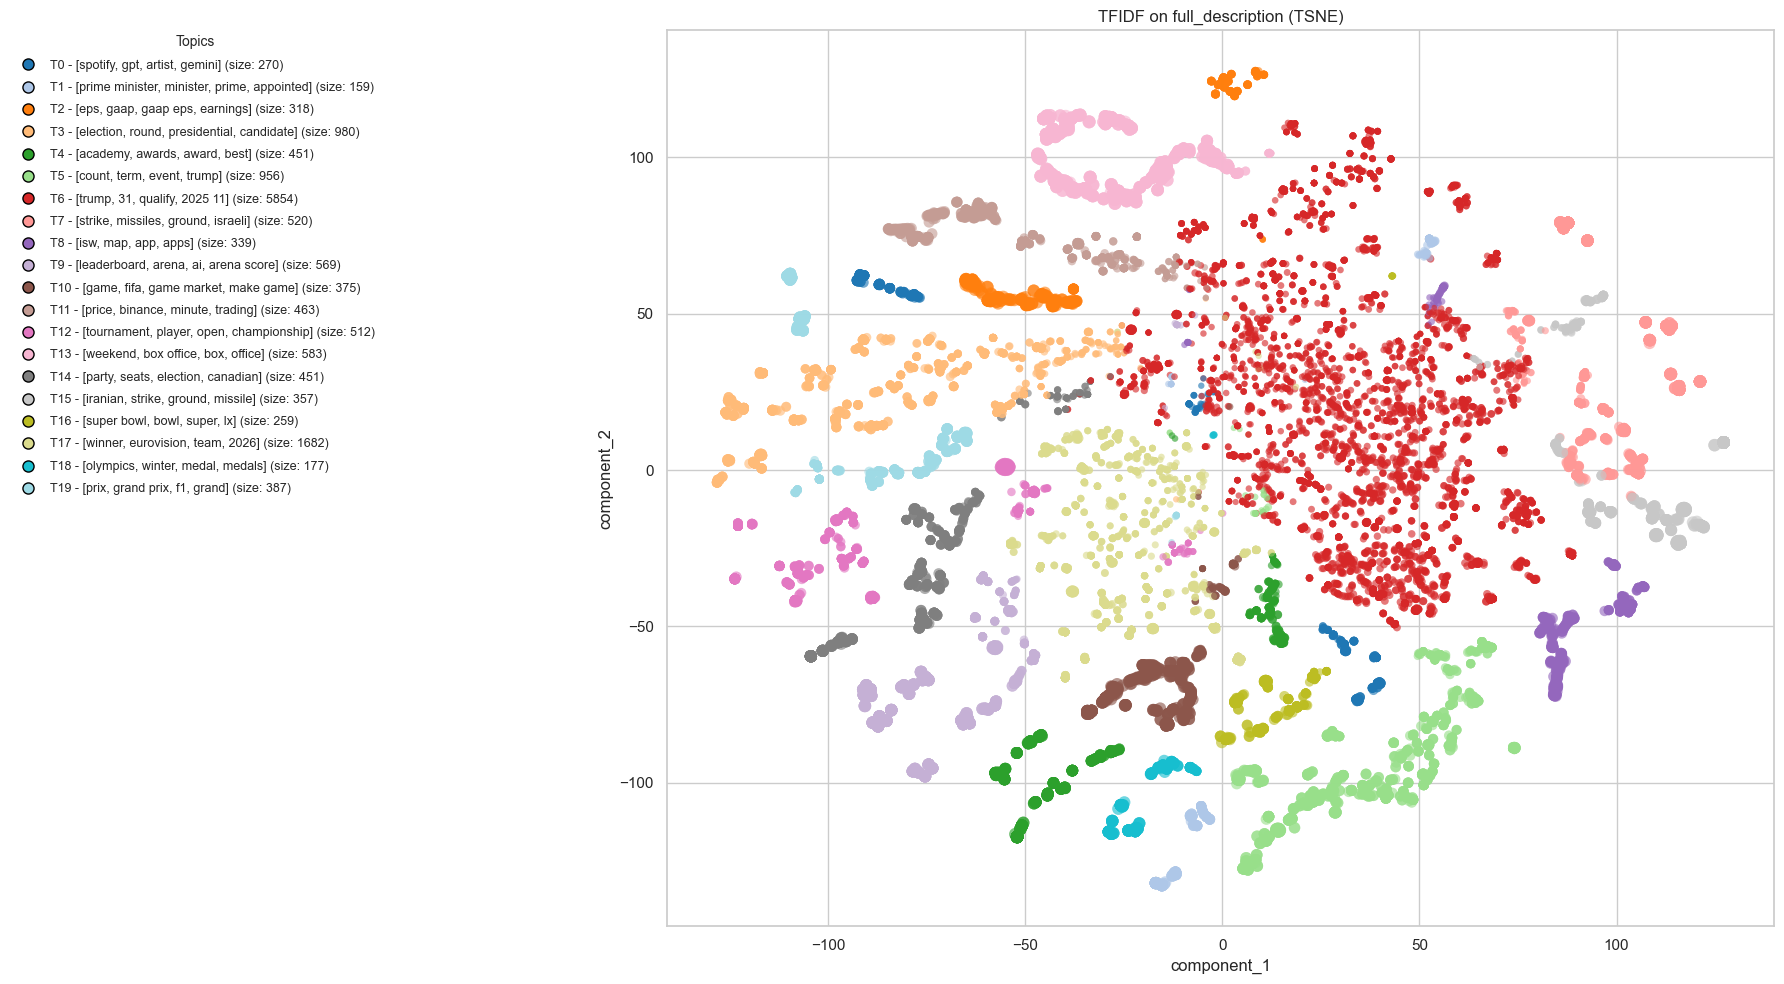

In [8]:
for model_name, result in results.items():
    fig, axes, projected = result.plot_2d_with_topic_map(
        reducer="tsne",
        random_state=0,
        legend_mode="full",
        show_table=False,
        figsize=(18, 10),
    )
    plt.show()

In [9]:
TOP_DOCS_PER_TOPIC = 2
s3_model = results["S3"]

print("=" * 100)
print("Representative documents for S3")
display(
    s3_model.representative_documents(top_n=TOP_DOCS_PER_TOPIC)[
        ["market_id", "topic_id", "topic_confidence", "topic_label", "question", "full_description"]
    ]
)


Representative documents for S3


,market_id,topic_id,topic_confidence,topic_label,question,full_description
0,556562,0,0.806450,"topic_0: binance minute, yes binance, market binance, btc usdt",XRP above $2.10 on July 4?,"This market will resolve to ""Yes"" if the Binance 1 minute candle for XRP/USDT 12:00 in the ET timezone (noon) on the date specified in the title has a final “Close” price higher than the price specified in the title. Otherwise, this market will resolve to ""No"". The resolution source for this market is Binance, specifically the XRP/USDT ""Close"" prices currently available at https://www.binance.com/en/trade/XRP_USDT with “1m” and “Candles” selected on the top bar. Please note that this market is about the price according to Binance XRP/USDT, not according to other sources or spot markets. Price precision is determined by the number of decimal places in the source. XRP above $2.10 on July 4?"
1,560178,0,0.804978,"topic_0: binance minute, yes binance, market binance, btc usdt",XRP above $2.20 on July 11?,"This market will resolve to ""Yes"" if the Binance 1 minute candle for XRP/USDT 12:00 in the ET timezone (noon) on the date specified in the title has a final “Close” price higher than the price specified in the title. Otherwise, this market will resolve to ""No"". The resolution source for this market is Binance, specifically the XRP/USDT ""Close"" prices currently available at https://www.binance.com/en/trade/XRP_USDT with “1m” and “Candles” selected on the top bar. Please note that this market is about the price according to Binance XRP/USDT, not according to other sources or spot markets. Price precision is determined by the number of decimal places in the source. XRP above $2.20 on July 11?"
2,908048,1,0.630583,"topic_1: people 2025, global people, 2025 winner, winner 2025",Will December 2025 be the 2nd hottest on record?,"This market will resolve based on the data for the Global Land-Ocean Temperature Index for December 2025 versus the data points available for all other Decembers on record. Note: If December 2025 is tied for first, second, or third hottest with another year, it will qualify for the bracket it ties with. The primary resolution source for this market will be the figures found in the table titled ""GLOBAL Land-Ocean Temperature Index in 0.01 degrees Celsius"" under the column ""Dec"" (https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.txt). If NASA's ""Global Temperature Index"" is rendered permanently unavailable, other information from NASA may be used. If no information for December 2025 is provided by NASA by January 31, 2026, 11:59 PM ET, a consensus of credible sources will be used to resolve this market. 2025 December 1st, 2nd, 3rd hottest on record?"
3,908049,1,0.630583,"topic_1: people 2025, global people, 2025 winner, winner 2025",Will December 2025 be the 3rd hottest on record?,"This market will resolve based on the data for the Global Land-Ocean Temperature Index for December 2025 versus the data points available for all other Decembers on record. Note: If December 2025 is tied for first, second, or third hottest with another year, it will qualify for the bracket it ties with. The primary resolution source for this market will be the figures found in the table titled ""GLOBAL Land-Ocean Temperature Index in 0.01 degrees Celsius"" under the column ""Dec"" (https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.txt). If NASA's ""Global Temperature Index"" is rendered permanently unavailable, other information from NASA may be used. If no information for December 2025 is provided by NASA by January 31, 2026, 11:59 PM ET, a consensus of credible sources will be used to resolve this market. 2025 December 1st, 2nd, 3rd hottest on record?"
4,518332,2,0.388561,"topic_2: 2025 gross, 2025 canadian, september 2025, march 2025",Will the Liberal–National Coalition win the most seats in the next Australian parliamentary election?,"The 2025 Australian federal election will be held on or before 17 May 2025 to

## Enrichment With The Fitted S3 Model

Once the S3 model is fitted, use it as a reusable enrichment artifact. 
Apply it either to new market-shaped rows or to raw free-text descriptions.


In [10]:
# The fitted S3 artifact can enrich either market rows or raw descriptions.
s3_model = results["S3"]

# 1. Enrich market-shaped rows.
example_new_markets = work_markets[["market_id", "question", "full_description"]].head(5).copy()
display(
    s3_model.infer_markets(example_new_markets)[
        ["market_id", "topic_id", "topic_confidence", "topic_label", "topic_terms", "question"]
    ]
)

# 2. Enrich raw descriptions directly.
example_new_descriptions = pd.Series([
    "Will the Fed cut rates by the September 2026 meeting?",
    "Will Nvidia close above $200 before the end of June 2026?",
    "Will Bitcoin trade above $150k in 2026?",
], name="description")

display(
    s3_model.infer_descriptions(example_new_descriptions)[
        ["input_index", "text_used", "topic_id", "topic_confidence", "topic_label", "topic_terms"]
    ]
)


,market_id,topic_id,topic_confidence,topic_label,topic_terms,question
10885,546814,10,0.184445,"topic_10: cast, film comes, market yes, yes according","cast, film comes, market yes, yes according, legal, videos released, yes named, yes market",Will Zelenskyy wear a suit before July?
7535,601697,16,0.323083,"topic_16: spotify week, top10 netflix, spotify com, streamed spotify","spotify week, top10 netflix, spotify com, streamed spotify, spotify, information spotify, ranks netflix, streamed song",Fed decreases interest rates by 50+ bps after January 2026 meeting?
7532,601700,16,0.323083,"topic_16: spotify week, top10 netflix, spotify com, streamed spotify","spotify week, top10 netflix, spotify com, streamed spotify, spotify, information spotify, ranks netflix, streamed song",Fed increases interest rates by 25+ bps after January 2026 meeting?
5856,654415,16,0.327448,"topic_16: spotify week, top10 netflix, spotify com, streamed spotify","spotify week, top10 netflix, spotify com, streamed spotify, spotify, information spotify, ranks netflix, streamed song",Will the Fed increase interest rates by 25+ bps after the March 2026 meeting?
8854,570360,16,0.321815,"topic_16: spotify week, top10 netflix, spotify com, streamed spotify","spotify week, top10 netflix, spotify com, streamed spotify, spotify, information spotify, ranks netflix, streamed song",Fed decreases interest rates by 50+ bps after December 2025 meeting?


,input_index,text_used,topic_id,topic_confidence,topic_label,topic_terms
0,0,Will the Fed cut rates by the September 2026 meeting?,2,0.308461,"topic_2: 2025 gross, 2025 canadian, september 2025, march 2025","2025 gross, 2025 canadian, september 2025, march 2025, 2025 2025, 2025 10, 2026 possible, 2025 elect"
1,1,Will Nvidia close above $200 before the end of June 2026?,0,0.225920,"topic_0: binance minute, yes binance, market binance, btc usdt","binance minute, yes binance, market binance, btc usdt, binance, 1m candles, binance com, www binance"
2,2,Will Bitcoin trade above $150k in 2026?,0,0.225087,"topic_0: binance minute, yes binance, market binance, btc usdt","binance minute, yes binance, market binance, btc usdt, binance, 1m candles, binance com, www binance"


## Why S3 Is The Working Default

We currently treat **S3** as the working default because it gave the best visual topic separation in this notebook. 
The cells below make that choice explicit in a paper-friendly way: a compact quantitative summary plus a small manual-review table.


/var/folders/zv/mjsbg2dx4q79c1gbwtlhbk180000gp/T/ipykernel_99676/2936633264.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_plot, x="model_name", y="mean_topic_confidence", ax=axes[0], palette="deep")
/var/folders/zv/mjsbg2dx4q79c1gbwtlhbk180000gp/T/ipykernel_99676/2936633264.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_plot, x="model_name", y="runtime_seconds", ax=axes[1], palette="deep")


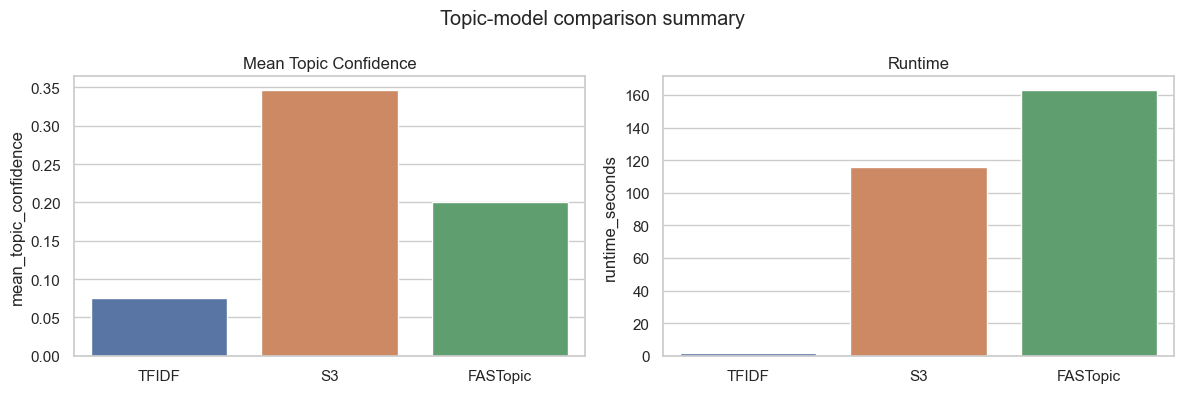

In [39]:
comparison_plot = comparison_summary.copy()
comparison_plot = comparison_plot.sort_values("runtime_seconds").reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=comparison_plot, x="model_name", y="mean_topic_confidence", ax=axes[0], palette="deep")
axes[0].set_title("Mean Topic Confidence")
axes[0].set_xlabel("")
axes[0].set_ylabel("mean_topic_confidence")

sns.barplot(data=comparison_plot, x="model_name", y="runtime_seconds", ax=axes[1], palette="deep")
axes[1].set_title("Runtime")
axes[1].set_xlabel("")
axes[1].set_ylabel("runtime_seconds")

fig.suptitle("Topic-model comparison summary")
fig.tight_layout()


In [40]:
model_review_notes = pd.DataFrame([
    {
        "model_name": "S3",
        "visual_separation": "best",
        "topic_coherence_note": "working default after visual review",
        "decision": "selected",
    },
    {
        "model_name": "FASTopic",
        "visual_separation": "review",
        "topic_coherence_note": "keep as strong neural baseline",
        "decision": "baseline",
    },
    {
        "model_name": "TFIDF",
        "visual_separation": "review",
        "topic_coherence_note": "keep as sparse lexical baseline",
        "decision": "baseline",
    },
])

display(model_review_notes)


,model_name,visual_separation,topic_coherence_note,decision
0,S3,best,working default after visual review,selected
1,FASTopic,review,keep as strong neural baseline,baseline
2,TFIDF,review,keep as sparse lexical baseline,baseline


## S3 Topic Labeling Prompt Builder

Build a compact text payload for manual/LLM topic naming. 
For each topic we include the top 5 representative documents and 5 additional random documents from the same topic. 
The final block ends with a default mapping dictionary that can be edited in-place.


In [41]:
TOP_REPRESENTATIVES_FOR_LABELING = 3
RANDOM_DOCS_FOR_LABELING = 7
LABELING_RANDOM_STATE = 0

s3_model = results["S3"]
s3_docs_for_labeling = s3_model.documents[[
    "topic_id",
    "topic_confidence",
    "question",
]].copy()


In [42]:
def _build_topic_labeling_prompt(topic_model, top_k: int = 5, random_k: int = 5, random_state: int = 0) -> str:
    topic_summaries = topic_model.topic_summary().sort_values("topic_id").reset_index(drop=True)
    docs = topic_model.documents[["topic_id", "topic_confidence", "question"]].copy()

    lines = []
    lines.append("Choose short, human-readable names for the following S3 topics.")
    lines.append("Use the representative and random documents to infer a clean title for each topic.")
    lines.append("Prefer concrete event-family names over lexical keyword lists.")
    lines.append("")

    for row in topic_summaries.itertuples(index=False):
        topic_id = int(row.topic_id)
        topic_key = f"topic_{topic_id}"
        topic_docs = docs.loc[docs["topic_id"] == topic_id].copy()
        topic_docs = topic_docs.sort_values("topic_confidence", ascending=False).reset_index(drop=True)

        top_docs = topic_docs.head(top_k).copy()
        remaining = topic_docs.iloc[top_k:].copy()
        if len(remaining) > 0:
            random_docs = remaining.sample(n=min(random_k, len(remaining)), random_state=random_state)
        else:
            random_docs = remaining.head(0).copy()

        lines.append(f"{topic_key}")
        lines.append(f"Current label: {row.topic_label}")
        lines.append(f"Current terms: {row.topic_terms}")
        lines.append(f"Topic size: {int(row.topic_size)}")
        lines.append("Top 5 representative documents:")
        for idx, doc in enumerate(top_docs.itertuples(index=False), start=1):
            lines.append(f"  R{idx}. {doc.question}")
        lines.append("Random 5 additional documents:")
        for idx, doc in enumerate(random_docs.itertuples(index=False), start=1):
            lines.append(f"  X{idx}. {doc.question}")
        lines.append("")

    default_mapping = {f"topic_{int(row.topic_id)}": f"topic_{int(row.topic_id)}" for row in topic_summaries.itertuples(index=False)}
    lines.append("Return only a Python dict with one short title per topic, starting from this default skeleton:")
    lines.append(str(default_mapping))
    return "\n".join(lines)


s3_topic_labeling_prompt = _build_topic_labeling_prompt(
    s3_model,
    top_k=TOP_REPRESENTATIVES_FOR_LABELING,
    random_k=RANDOM_DOCS_FOR_LABELING,
    random_state=LABELING_RANDOM_STATE,
)

print(s3_topic_labeling_prompt)


Choose short, human-readable names for the following S3 topics.
Use the representative and random documents to infer a clean title for each topic.
Prefer concrete event-family names over lexical keyword lists.

topic_0
Current label: topic_0: binance minute, yes binance, market binance, btc usdt
Current terms: binance minute, yes binance, market binance, btc usdt, binance, 1m candles, binance com, www binance
Topic size: 843
Top 5 representative documents:
  R1. XRP above $2.10 on July 4?
  R2. XRP above $2.20 on July 11?
  R3. XRP above $3.10 on August 1?
Random 5 additional documents:
  X1. Will Sky win the USDH ticker?
  X2. Will Bitcoin dip to $50,000 by March 31?
  X3. Will Kanye name his token Jew?
  X4. Dogecoin above $0.34 on January 17?
  X5. Will $TRUMP hit $25B FDV by Sunday?
  X6. Will $Trump FDV be $15b or more on inauguration day?
  X7. Hyperliquid daily fees above $8M in 2025?

topic_1
Current label: topic_1: people 2025, global people, 2025 winner, winner 2025
Current t

## Topic Assignment Artifact

Build an export-ready market-to-topic table from the fitted S3 model. This is the main annotation artifact to join back onto canonical markets.


In [50]:
ai_topic_names = {
    'topic_0': 'Crypto Price Targets',
    'topic_1': 'Year-End 2025 Superlatives',
    'topic_2': 'Election And 2025 Macro Outcomes',
    'topic_3': 'Speech Word-Usage Markets',
    'topic_4': 'Miscellaneous Political And Macro Events',
    'topic_5': 'Iran Strike Escalation',
    'topic_6': 'Opening Weekend Box Office',
    'topic_7': 'Trump Bilateral Meetings',
    'topic_8': 'Mayoral Elections',
    'topic_9': 'Mixed Policy And Resolution Markets',
    'topic_10': 'Miscellaneous Public-Event Outcomes',
    'topic_11': 'US-Venezuela Escalation',
    'topic_12': 'Recognition And Geopolitical Status',
    'topic_13': 'NFL And Big Game Markets',
    'topic_14': 'Russia Territorial Advances',
    'topic_15': 'International Football Matches',
    'topic_16': 'Streaming Charts',
    'topic_17': 'Mixed Politics And Elon Markets',
    'topic_18': 'Quarterly Earnings Beats',
    'topic_19': 'Trump Tariffs And Mixed Politics'
}

In [51]:
ai_category_names = {
    'topic_0': 'Crypto',
    'topic_1': 'Year-End Rankings',
    'topic_2': 'Elections And Macro',
    'topic_3': 'Speech And Language',
    'topic_4': 'Politics And Macro',
    'topic_5': 'Geopolitics',
    'topic_6': 'Entertainment',
    'topic_7': 'Trump And Diplomacy',
    'topic_8': 'Elections',
    'topic_9': 'Policy And Resolution',
    'topic_10': 'Miscellaneous Public Events',
    'topic_11': 'Geopolitics',
    'topic_12': 'Geopolitical Recognition',
    'topic_13': 'Sports',
    'topic_14': 'Geopolitics',
    'topic_15': 'Sports',
    'topic_16': 'Streaming And Charts',
    'topic_17': 'Politics And Elon',
    'topic_18': 'Earnings',
    'topic_19': 'Trump Policy'
}


In [52]:
s3_model = results["S3"]

s3_topic_assignments = s3_model.documents[[
    "market_id",
    "topic_id",
    "topic_confidence",
    "topic_label",
    "topic_terms",
]].copy()

s3_topic_assignments["topic_name"] = s3_topic_assignments["topic_id"].map(
    lambda value: ai_topic_names.get(f"topic_{int(value)}", f"topic_{int(value)}")
)
s3_topic_assignments["category_name"] = s3_topic_assignments["topic_id"].map(
    lambda value: ai_category_names.get(f"topic_{int(value)}", "Uncategorized")
)
s3_topic_assignments["topic_model_name"] = s3_model.model_name
s3_topic_assignments["topic_text_mode"] = s3_model.text_mode
s3_topic_assignments["topic_model_version"] = "s3_v1"

# Optional stable column ordering for downstream joins.
s3_topic_assignments = s3_topic_assignments[[
    "market_id",
    "topic_id",
    "topic_name",
    "category_name",
    "topic_confidence",
    "topic_label",
    "topic_terms",
    "topic_model_name",
    "topic_text_mode",
    "topic_model_version",
]]

display(s3_topic_assignments.head(10))


,market_id,topic_id,topic_name,category_name,topic_confidence,topic_label,topic_terms,topic_model_name,topic_text_mode,topic_model_version
0,546814,10,Miscellaneous Public-Event Outcomes,Miscellaneous Public Events,0.184445,"topic_10: cast, film comes, market yes, yes according","cast, film comes, market yes, yes according, legal, videos released, yes named, yes market",S3,full_description,s3_v1
1,601697,16,Streaming Charts,Streaming And Charts,0.323083,"topic_16: spotify week, top10 netflix, spotify com, streamed spotify","spotify week, top10 netflix, spotify com, streamed spotify, spotify, information spotify, ranks netflix, streamed song",S3,full_description,s3_v1
2,601700,16,Streaming Charts,Streaming And Charts,0.323083,"topic_16: spotify week, top10 netflix, spotify com, streamed spotify","spotify week, top10 netflix, spotify com, streamed spotify, spotify, information spotify, ranks netflix, streamed song",S3,full_description,s3_v1
3,654415,16,Streaming Charts,Streaming And Charts,0.327448,"topic_16: spotify week, top10 netflix, spotify com, streamed spotify","spotify week, top10 netflix, spotify com, streamed spotify, spotify, information spotify, ranks netflix, streamed song",S3,full_description,s3_v1
4,570360,16,Streaming Charts,Streaming And Charts,0.321815,"topic_16: spotify week, top10 netflix, spotify com, streamed spotify","spotify week, top10 netflix, spotify com, streamed spotify, spotify, information spotify, ranks netflix, streamed song",S3,full_description,s3_v1
5,680392,17,Mixed Politics And Elon Markets,Politics And Elon,0.219476,"topic_17: interim caretaker, mayor bucharest, tesla, cpi release","interim caretaker, mayor bucharest, tesla, cpi release, cpi, police station, resignation, resignation removal",S3,full_description,s3_v1
6,538932,8,Mayoral Elections,Elections,0.399735,"topic_8: mayoral election, city mayoral, nyc mayoral, mayoral","mayoral election, city mayoral, nyc mayoral, mayoral, city average, bucharest mayoral, mayor, mayor bucharest",S3,full_description,s3_v1
7,570363,16,Streaming Charts,Streaming And Charts,0.321815,"topic_16: spotify week, top10 netflix, spotify com, streamed spotify","spotify week, top10 netflix, spotify com, streamed spotify, spotify, information spotify, ranks netflix, streamed song",S3,full_description,s3_v1
8,1180303,5,Iran Strike Escalation,Geopolitics,0.221894,"topic_5: strike iranian, strikes iran, impact iranian, iranian ground","strike iranian, strikes iran, impact iranian, iranian ground, iranian, iranian soil, iranian territory, official iranian",S3,full_description,s3_v1
9,529278,15,International Football Matches,Sports,0.194942,"topic_15: uefa, fifa, time fifa, uefa champions","uefa, fifa, time fifa, uefa champions, upcoming fifa, europa eu, bucharest, fifa com",S3,full_description,s3_v1


## Topic-To-Benchmark Features

Derive benchmark-facing features from the fitted S3 topic mixture. These are the compact signals most likely to be useful in forecasting or retrieval benchmarks.


In [53]:
import numpy as np

s3_topic_matrix = pd.DataFrame(
    s3_model.doc_topic_matrix,
    index=s3_model.documents.index,
    columns=[f"topic_score_{int(topic_id)}" for topic_id in s3_model.topics["topic_id"]],
)

s3_topic_features = pd.concat(
    [
        s3_model.documents[["market_id", "topic_id", "topic_confidence"]]
        .assign(
            topic_name=lambda frame: frame["topic_id"].map(
                lambda value: ai_topic_names.get(f"topic_{int(value)}", f"topic_{int(value)}")
            ),
            category_name=lambda frame: frame["topic_id"].map(
                lambda value: ai_category_names.get(f"topic_{int(value)}", "Uncategorized")
            ),
        )
        .reset_index(drop=True),
        s3_topic_matrix.reset_index(drop=True),
    ],
    axis=1,
)

sorted_scores = np.sort(s3_model.doc_topic_matrix, axis=1)[:, ::-1]
s3_topic_features["topic_entropy"] = -np.sum(
    np.clip(s3_model.doc_topic_matrix, 1e-12, 1.0) * np.log(np.clip(s3_model.doc_topic_matrix, 1e-12, 1.0)),
    axis=1,
)
s3_topic_features["topic_top2_margin"] = sorted_scores[:, 0] - sorted_scores[:, 1]
s3_topic_features["topic_model_name"] = s3_model.model_name
s3_topic_features["topic_model_version"] = "s3_v1"

display(s3_topic_features.head(10))


,market_id,topic_id,topic_confidence,topic_name,category_name,topic_score_0,topic_score_1,topic_score_2,topic_score_3,topic_score_4,topic_score_5,topic_score_6,topic_score_7,topic_score_8,topic_score_9,topic_score_10,topic_score_11,topic_score_12,topic_score_13,topic_score_14,topic_score_15,topic_score_16,topic_score_17,topic_score_18,topic_score_19,topic_entropy,topic_top2_margin,topic_model_name,topic_model_version
0,546814,10,0.184445,Miscellaneous Public-Event Outcomes,Miscellaneous Public Events,0.065443,0.133301,0.107268,0.0,0.072872,0.000000,0.052877,0.054816,0.024860,0.000000,0.184445,0.103607,0.000000,0.000000,0.074315,0.001990,0.000000,0.077554,0.046653,0.000000,2.377357,0.051145,S3,s3_v1
1,601697,16,0.323083,Streaming Charts,Streaming And Charts,0.053327,0.000000,0.019805,0.0,0.090707,0.058301,0.000000,0.022063,0.049908,0.110259,0.000000,0.000000,0.000000,0.000000,0.000000,0.006775,0.323083,0.000000,0.252645,0.013128,1.897592,0.070438,S3,s3_v1
2,601700,16,0.323083,Streaming Charts,Streaming And Charts,0.053327,0.000000,0.019805,0.0,0.090707,0.058301,0.000000,0.022063,0.049908,0.110259,0.000000,0.000000,0.000000,0.000000,0.000000,0.006775,0.323083,0.000000,0.252645,0.013128,1.897592,0.070438,S3,s3_v1
3,654415,16,0.327448,Streaming Charts,Streaming And Charts,0.049666,0.000000,0.026872,0.0,0.086378,0.053934,0.000000,0.016798,0.045522,0.115392,0.000000,0.000000,0.000000,0.000000,0.000000,0.006375,0.327448,0.000000,0.256365,0.015250,1.884346,0.071083,S3,s3_v1
4,570360,16,0.321815,Streaming Charts,Streaming And Charts,0.045987,0.000000,0.025635,0.0,0.097608,0.057984,0.000000,0.013706,0.048980,0.119663,0.000000,0.000000,0.000000,0.000000,0.000000,0.005349,0.321815,0.000000,0.251868,0.011405,1.879511,0.069948,S3,s3_v1
5,680392,17,0.219476,Mixed Politics And Elon Markets,Politics And Elon,0.000000,0.000000,0.122665,0.0,0.144970,0.000000,0.196357,0.000000,0.000000,0.082701,0.000000,0.000000,0.000000,0.112448,0.000000,0.000000,0.000000,0.219476,0.000000,0.121384,1.897666,0.023119,S3,s3_v1
6,538932,8,0.399735,Mayoral Elections,Elections,0.000000,0.149813,0.125425,0.0,0.074414,0.000000,0.000000,0.002299,0.399735,0.000000,0.019060,0.000000,0.000000,0.046252,0.000000,0.000000,0.000000,0.171261,0.000000,0.011740,1.690654,0.228474,S3,s3_v1
7,570363,16,0.321815,Streaming Charts,Streaming And Charts,0.045987,0.000000,0.025635,0.0,0.097608,0.057984,0.000000,0.013706,0.048980,0.119663,0.000000,0.000000,0.000000,0.000000,0.000000,0.005349,0.321815,0.000000,0.251868,0.011405,1.879511,0.069948,S3,s3_v1
8,1180303,5,0.221894,Iran Strike Escalation,Geopolitics,0.000000,0.071111,0.023673,0.0,0.061207,0.221894,0.000000,0.044728,0.000000,0.079676,0.205179,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.156642,0.073699,0.062190,2.102482,0.016715,S3,s3_v1
9,529278,15,0.194942,International Football Matches,Sports,0.000000,0.095231,0.110372,0.0,0.000000,0.041646,0.000000,0.132963,0.077851,0.000000,0.003761,0.000000,0.135917,0.000000,0.000000,0.194942,0.000000,0.101563,0.016511,0.089243,2.193256,0.059025,S3,s3_v1


## Export Cells

Write the main S3 artifacts to disk so they can be reused in benchmark code or paper analysis.


In [54]:
TOPIC_ARTEFACT_DIR = REPO_ROOT / "research_notebooks" / "running_artefacts_new" / "topic_models" / "s3_v1"
TOPIC_ARTEFACT_DIR.mkdir(parents=True, exist_ok=True)

s3_topic_assignments_export = s3_topic_assignments.copy()
s3_topic_assignments_export["topic_name"] = s3_topic_assignments_export["topic_id"].map(lambda value: ai_topic_names.get(f"topic_{int(value)}", f"topic_{int(value)}"))
s3_topic_assignments_export.to_parquet(TOPIC_ARTEFACT_DIR / "topic_assignments.parquet", index=False)
s3_topic_features.to_parquet(TOPIC_ARTEFACT_DIR / "topic_features.parquet", index=False)
s3_topic_summary_export = s3_model.topic_summary().copy()
s3_topic_summary_export["topic_name"] = s3_topic_summary_export["topic_id"].map(lambda value: ai_topic_names.get(f"topic_{int(value)}", f"topic_{int(value)}"))
s3_topic_summary_export["category_name"] = s3_topic_summary_export["topic_id"].map(lambda value: ai_category_names.get(f"topic_{int(value)}", "Uncategorized"))
s3_topic_summary_export.to_parquet(TOPIC_ARTEFACT_DIR / "topic_summary.parquet", index=False)
comparison_summary.to_parquet(TOPIC_ARTEFACT_DIR / "model_comparison_summary.parquet", index=False)

ai_topic_name_mapping = pd.DataFrame(
    [
        {
            "topic_key": key,
            "topic_name": value,
            "category_name": ai_category_names.get(key, "Uncategorized"),
        }
        for key, value in ai_topic_names.items()
    ]
)
ai_topic_name_mapping.to_parquet(TOPIC_ARTEFACT_DIR / "topic_name_mapping.parquet", index=False)

artifact_metadata = pd.DataFrame([
    {
        "topic_model_name": s3_model.model_name,
        "topic_model_version": "s3_v1",
        "text_mode": s3_model.text_mode,
        "n_topics": len(s3_model.topics),
        "n_documents": len(s3_model.documents),
        "market_limit": MARKET_LIMIT,
        "market_order": MARKET_ORDER,
        "selected_by_visual_review": True,
    }
])
artifact_metadata.to_parquet(TOPIC_ARTEFACT_DIR / "artifact_metadata.parquet", index=False)

print("Saved topic artefacts to:", TOPIC_ARTEFACT_DIR)


Saved topic artefacts to: /Users/sneddy/research/polymarket_research/research_notebooks/running_artefacts_new/topic_models/s3_v1


In [55]:
s3_topic_assignments

,market_id,topic_id,topic_name,category_name,topic_confidence,topic_label,topic_terms,topic_model_name,topic_text_mode,topic_model_version
0,546814,10,Miscellaneous Public-Event Outcomes,Miscellaneous Public Events,0.184445,"topic_10: cast, film comes, market yes, yes according","cast, film comes, market yes, yes according, legal, videos released, yes named, yes market",S3,full_description,s3_v1
1,601697,16,Streaming Charts,Streaming And Charts,0.323083,"topic_16: spotify week, top10 netflix, spotify com, streamed spotify","spotify week, top10 netflix, spotify com, streamed spotify, spotify, information spotify, ranks netflix, streamed song",S3,full_description,s3_v1
2,601700,16,Streaming Charts,Streaming And Charts,0.323083,"topic_16: spotify week, top10 netflix, spotify com, streamed spotify","spotify week, top10 netflix, spotify com, streamed spotify, spotify, information spotify, ranks netflix, streamed song",S3,full_description,s3_v1
3,654415,16,Streaming Charts,Streaming And Charts,0.327448,"topic_16: spotify week, top10 netflix, spotify com, streamed spotify","spotify week, top10 netflix, spotify com, streamed spotify, spotify, information spotify, ranks netflix, streamed song",S3,full_description,s3_v1
4,570360,16,Streaming Charts,Streaming And Charts,0.321815,"topic_16: spotify week, top10 netflix, spotify com, streamed spotify","spotify week, top10 netflix, spotify com, streamed spotify, spotify, information spotify, ranks netflix, streamed song",S3,full_description,s3_v1
...,...,...,...,...,...,...,...,...,...,...
15657,522061,9,Mixed Policy And Resolution Markets,Policy And Resolution,0.192175,"topic_9: disruption market, eliminated market, coalition market, strike lebanese","disruption market, eliminated market, coalition market, strike lebanese, resolve market, market resolution, resolution market, 25 basis",S3,full_description,s3_v1
15658,1329169,4,Miscellaneous Political And Macro Events,Politics And Macro,0.338986,"topic_4: leavitt, zelenskyy, jerome, milano","leavitt, zelenskyy, jerome, milano, claude, market bloomberg, canadian federal, nhl",S3,full_description,s3_v1
15659,558333,7,Trump Bilateral Meetings,Trump And Diplomacy,0.290664,"topic_7: trump meet, meets donald, bilateral meeting, individual meets","trump meet, meets donald, bilateral meeting, individual meets, meeting scheduled, handshake donald, meet, trump scheduled",S3,full_description,s3_v1
15660,670076,15,International Football Matches,Sports,0.212522,"topic_15: uefa, fifa, time fifa, uefa champions","uefa, fifa, time fifa, uefa champions, upcoming fifa, europa eu, bucharest, fifa com",S3,full_description,s3_v1


## Reload Exported Topic Artefacts

Example of how to load the exported topic artefacts back into a notebook or benchmark script.


In [63]:
TOPIC_ARTEFACT_DIR = REPO_ROOT / "research_notebooks" / "running_artefacts_new" / "topic_models" / "s3_v1"

loaded_topic_assignments = pd.read_parquet(TOPIC_ARTEFACT_DIR / "topic_assignments.parquet")
loaded_topic_features = pd.read_parquet(TOPIC_ARTEFACT_DIR / "topic_features.parquet")
loaded_topic_summary = pd.read_parquet(TOPIC_ARTEFACT_DIR / "topic_summary.parquet")
loaded_topic_name_mapping = pd.read_parquet(TOPIC_ARTEFACT_DIR / "topic_name_mapping.parquet")
loaded_artifact_metadata = pd.read_parquet(TOPIC_ARTEFACT_DIR / "artifact_metadata.parquet")

display(loaded_topic_assignments.head(5))
display(loaded_topic_features.head(5))
display(loaded_topic_summary.head(5))


,market_id,topic_id,topic_name,category_name,topic_confidence,topic_label,topic_terms,topic_model_name,topic_text_mode,topic_model_version
0,546814,10,Miscellaneous Public-Event Outcomes,Miscellaneous Public Events,0.184445,"topic_10: cast, film comes, market yes, yes according","cast, film comes, market yes, yes according, legal, videos released, yes named, yes market",S3,full_description,s3_v1
1,601697,16,Streaming Charts,Streaming And Charts,0.323083,"topic_16: spotify week, top10 netflix, spotify com, streamed spotify","spotify week, top10 netflix, spotify com, streamed spotify, spotify, information spotify, ranks netflix, streamed song",S3,full_description,s3_v1
2,601700,16,Streaming Charts,Streaming And Charts,0.323083,"topic_16: spotify week, top10 netflix, spotify com, streamed spotify","spotify week, top10 netflix, spotify com, streamed spotify, spotify, information spotify, ranks netflix, streamed song",S3,full_description,s3_v1
3,654415,16,Streaming Charts,Streaming And Charts,0.327448,"topic_16: spotify week, top10 netflix, spotify com, streamed spotify","spotify week, top10 netflix, spotify com, streamed spotify, spotify, information spotify, ranks netflix, streamed song",S3,full_description,s3_v1
4,570360,16,Streaming Charts,Streaming And Charts,0.321815,"topic_16: spotify week, top10 netflix, spotify com, streamed spotify","spotify week, top10 netflix, spotify com, streamed spotify, spotify, information spotify, ranks netflix, streamed song",S3,full_description,s3_v1


,market_id,topic_id,topic_confidence,topic_name,category_name,topic_score_0,topic_score_1,topic_score_2,topic_score_3,topic_score_4,topic_score_5,topic_score_6,topic_score_7,topic_score_8,topic_score_9,topic_score_10,topic_score_11,topic_score_12,topic_score_13,topic_score_14,topic_score_15,topic_score_16,topic_score_17,topic_score_18,topic_score_19,topic_entropy,topic_top2_margin,topic_model_name,topic_model_version
0,546814,10,0.184445,Miscellaneous Public-Event Outcomes,Miscellaneous Public Events,0.065443,0.133301,0.107268,0.0,0.072872,0.000000,0.052877,0.054816,0.024860,0.000000,0.184445,0.103607,0.0,0.0,0.074315,0.001990,0.000000,0.077554,0.046653,0.000000,2.377357,0.051145,S3,s3_v1
1,601697,16,0.323083,Streaming Charts,Streaming And Charts,0.053327,0.000000,0.019805,0.0,0.090707,0.058301,0.000000,0.022063,0.049908,0.110259,0.000000,0.000000,0.0,0.0,0.000000,0.006775,0.323083,0.000000,0.252645,0.013128,1.897592,0.070438,S3,s3_v1
2,601700,16,0.323083,Streaming Charts,Streaming And Charts,0.053327,0.000000,0.019805,0.0,0.090707,0.058301,0.000000,0.022063,0.049908,0.110259,0.000000,0.000000,0.0,0.0,0.000000,0.006775,0.323083,0.000000,0.252645,0.013128,1.897592,0.070438,S3,s3_v1
3,654415,16,0.327448,Streaming Charts,Streaming And Charts,0.049666,0.000000,0.026872,0.0,0.086378,0.053934,0.000000,0.016798,0.045522,0.115392,0.000000,0.000000,0.0,0.0,0.000000,0.006375,0.327448,0.000000,0.256365,0.015250,1.884346,0.071083,S3,s3_v1
4,570360,16,0.321815,Streaming Charts,Streaming And Charts,0.045987,0.000000,0.025635,0.0,0.097608,0.057984,0.000000,0.013706,0.048980,0.119663,0.000000,0.000000,0.0,0.0,0.000000,0.005349,0.321815,0.000000,0.251868,0.011405,1.879511,0.069948,S3,s3_v1


,topic_id,topic_terms,topic_label,topic_size,topic_name,category_name
0,15,"uefa, fifa, time fifa, uefa champions, upcoming fifa, europa eu, bucharest, fifa com","topic_15: uefa, fifa, time fifa, uefa champions",1239,International Football Matches,Sports
1,1,"people 2025, global people, 2025 winner, winner 2025, yoon suk, olympics 2026, year 2025, resolve 2025","topic_1: people 2025, global people, 2025 winner, winner 2025",1039,Year-End 2025 Superlatives,Year-End Rankings
2,8,"mayoral election, city mayoral, nyc mayoral, mayoral, city average, bucharest mayoral, mayor, mayor bucharest","topic_8: mayoral election, city mayoral, nyc mayoral, mayoral",991,Mayoral Elections,Elections
3,10,"cast, film comes, market yes, yes according, legal, videos released, yes named, yes market","topic_10: cast, film comes, market yes, yes according",971,Miscellaneous Public-Event Outcomes,Miscellaneous Public Events
4,3,"context joyful, pluralization, words count, word joy, possessive term, compound words, word count, pluralization possessive","topic_3: context joyful, pluralization, words count, word joy",960,Speech Word-Usage Markets,Speech And Language


In [65]:
question2topic = (
    canonical.markets[["market_id", "question"]]
    .merge(
        loaded_topic_assignments[["market_id", "topic_name", "category_name"]],
        on="market_id",
        how="left",
    )
    .reset_index(drop=True)
)


In [ ]:

question2topic = s3_model.documents[["market_id", "question"]].merge(
    loaded_topic_assignments[["market_id", "topic_name", "category_name"]],
    on="market_id",
    how="left",
).reset_index(drop=True)


In [73]:
question2topic[question2topic.category_name == 'Speech And Language'].sample(15)

,market_id,question,topic_name,category_name
11063,545337,"Will Trump say ""Israel"" during events with South African President on May 21?",Speech Word-Usage Markets,Speech And Language
669,1390124,"Will Trump say ""Judy Shelton"" during the State of the Union address?",Speech Word-Usage Markets,Speech And Language
2162,1186416,"Will Trump say ""Make Iran Great Again"" during WEF Address on January 21?",Speech Word-Usage Markets,Speech And Language
11071,545270,"Will Trump say ""Crypto"" or ""Bitcoin"" this week?",Speech Word-Usage Markets,Speech And Language
5975,647088,"Will Amazon say ""RxPass"" during earnings call?",Speech Word-Usage Markets,Speech And Language
4279,791244,"Will Trump say ""Hell"" 4+ times during Cabinet Meeting on December 2?",Speech Word-Usage Markets,Speech And Language
6853,623750,"Will Trump say ""Tariff"" 3+ times during events with President of Finland on Oct 9?",Speech Word-Usage Markets,Speech And Language
4271,792131,"Will Trump say ""Thank You"" or ""Please"" 15+ times during Cabinet Meeting on December 2?",Speech Word-Usage Markets,Speech And Language
9192,564685,"Will anyone say ""Cloud"" during the Q4 2025 Microsoft earnings call?",Speech Word-Usage Markets,Speech And Language
12378,537178,"Will Trump say ""Italy"" 10+ times during Meloni visit on April 17?",Speech Word-Usage Markets,Speech And Language


In [69]:
question2topic[question2topic.category_name == 'Sports'].sample(15)

,market_id,question,topic_name,category_name
11473,541849,Will Carlos Alcaraz win the 2025 French Open?,International Football Matches,Sports
13738,525457,Will the St. Louis Cardinals win the 2025 National League Championship?,NFL And Big Game Markets,Sports
10929,546461,"Will ""Maybe Happy Ending"" win the Tony for Best Original Score 2025?",NFL And Big Game Markets,Sports
2691,1090127,Will Allstate run an Ad during Super Bowl LX?,NFL And Big Game Markets,Sports
13884,525101,Will Harry Kane be the top Champions League scorer?,International Football Matches,Sports
3962,823692,Will the Notre Dame Fighting Irish be the #9 seed in the 2025-2026 College Football Playoff?,NFL And Big Game Markets,Sports
12486,535773,Will Switzerland finish in the 2025 Eurovision top 10?,International Football Matches,Sports
4128,809538,Will Aristides Teixeira win the 1st round of the 2026 Portugal presidential election?,International Football Matches,Sports
15070,519074,Will Mircea Geoană win the Romanian presidential election?,International Football Matches,Sports
9619,558895,Will South Carolina win the 2026 College Football National Championship?,NFL And Big Game Markets,Sports


In [70]:
question2topic.category_name.value_counts()

category_name
Geopolitics                    2340
Sports                         2127
Year-End Rankings              1039
Elections                       991
Miscellaneous Public Events     971
Speech And Language             960
Trump And Diplomacy             940
Entertainment                   851
Crypto                          843
Politics And Elon               796
Earnings                        744
Streaming And Charts            742
Politics And Macro              579
Geopolitical Recognition        532
Trump Policy                    519
Elections And Macro             386
Policy And Resolution           302
Name: count, dtype: int64

In [72]:
question2topic[question2topic.category_name == 'Crypto'].sample(15)

,market_id,question,topic_name,category_name
11986,539462,Will Admire Daytona win the 2025 Kentucky Derby?,Crypto Price Targets,Crypto
8149,581517,Will there be a Powerball jackpot winner by September 14?,Crypto Price Targets,Crypto
13858,525169,Will Kanye launch a coin in March?,Crypto Price Targets,Crypto
319,1517488,Crude Oil all time high by March 31?,Crypto Price Targets,Crypto
13297,527828,Solana all time high before 2026?,Crypto Price Targets,Crypto
3514,938218,Over $50M committed to the Gensyn public sale?,Crypto Price Targets,Crypto
12960,530476,Will Kanye launch a coin before May?,Crypto Price Targets,Crypto
15427,517953,"Palisades fire burns 15,000-20,000 acres by Friday?",Crypto Price Targets,Crypto
9165,565922,MicroStrategy purchases >5000 BTC July 22-28?,Crypto Price Targets,Crypto
13571,526231,"Will Bitcoin reach $85,000 by March 31?",Crypto Price Targets,Crypto
